<a href="https://colab.research.google.com/github/Saheera-006/sdn/blob/main/nndl_practical_munnadi_naal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#ex1 vector addition
import tensorflow as tf
a=tf.constant([1,2,3,4])
b=tf.constant([5,6,7,8])
print("A matrix :",a)
print("B matrix :",b)
c=tf.add(a,b)
print("Addition of A and B matrix :",c)

A matrix : tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)
B matrix : tf.Tensor([5 6 7 8], shape=(4,), dtype=int32)
Addition of A and B matrix : tf.Tensor([ 6  8 10 12], shape=(4,), dtype=int32)


In [7]:
#ex2 regression model
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(0)
x=np.random.rand(100,1)
y=2*x.squeeze()+1+np.random.rand(100)*0.1

model=keras.Sequential([
    layers.Dense(10,activation='relu',input_shape=(1,)),
     layers.Dense(1)
     ])

model.compile(optimizer='adam',loss='mse')
model.fit(x,y,epochs=100,batch_size=32,verbose=0)
pred=model.predict(x)
for i in range(5):
  print("Predicted : ",pred[i][0] ,"\tTrue : ",y[i])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Predicted :  1.6433287 	True :  2.1654086615342725
Predicted :  1.836894 	True :  2.4573795300640557
Predicted :  1.710278 	True :  2.2790461543555476
Predicted :  1.6377032 	True :  2.1859852205055375
Predicted :  1.464189 	True :  1.8721849130298052


In [11]:
#ex 3 perceptron
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

x=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,1])

model=keras.Sequential([layers.Dense(1,activation="sigmoid",input_shape=(2,))])
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(x,y,epochs=100,verbose=0)

loss,accuracy=model.evaluate(x,y)
print("loss: ",loss)
print("Accuracy: ",accuracy)

pred=model.predict(x)
print("Predictions: ",pred.flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.2500 - loss: 0.8087
loss:  0.8086957931518555
Accuracy:  0.25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predictions:  [0.52434546 0.26548037 0.70659846 0.44121957]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.0000e+00 - loss: 0.9453
loss:  0.945257842540741
Accuracy:  0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predictions:  [0.52447885 0.47168514 0.34260175 0.296693  ]


In [16]:
#ex 4 feed forward ntw
import tensorflow as tf
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train,x_test=  x_train/255.0,x_test/255.0

model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(35,activation='relu'),
    Dense(21,activation='relu'),
    Dense(10,activation='softmax')])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=5,batch_size=32,verbose=1)

loss,accuracy=model.evaluate(x_test,y_test)
print("Loss: ",loss)
print("Accuracy: ",accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8999 - loss: 0.3446
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9493 - loss: 0.1673
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9599 - loss: 0.1312
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9661 - loss: 0.1110
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9701 - loss: 0.0980
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9676 - loss: 0.1108
Loss:  0.1108408197760582
Accuracy:  0.9675999879837036


In [ ]:
#ex 5 image classifier in cnn
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape to include channel dimension (grayscale → 1 channel)
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

# Define CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),  # Convolution layer
    MaxPooling2D((2,2)),                                          # Pooling layer
    Conv2D(64, (3,3), activation='relu'),                         # Another convolution
    MaxPooling2D((2,2)),                                          # Pooling
    Flatten(),                                                    # Flatten to vector
    Dense(64, activation='relu'),                                 # Fully connected
    Dense(10, activation='softmax')                               # Output (10 classes)
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=64, verbose=1)

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

In [30]:
#ex 6 Hyper parameter
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

x,y=make_classification(n_samples=1000,n_features=20,n_informative=10,n_classes=2,random_state=42)
param_dist={
    "max_depth":[3,None],
    "max_features":randint(1,9),
    "min_samples_leaf":randint(1,9),
    "criterion":["gini","entropy"]
}

tree_cv=RandomizedSearchCV(DecisionTreeClassifier(),param_dist,cv=5).fit(x,y)
print("Tuned Parameters: ",tree_cv.best_params_)
print("Best Score: ",tree_cv.best_score_)

Tuned Parameters:  {'criterion': 'entropy', 'max_depth': None, 'max_features': 6, 'min_samples_leaf': 4}
Best Score:  0.817


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 400s 250ms/step - accuracy: 0.2553 - loss: 2.0340 - val_accuracy: 0.3166 - val_loss: 1.8757
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: frog


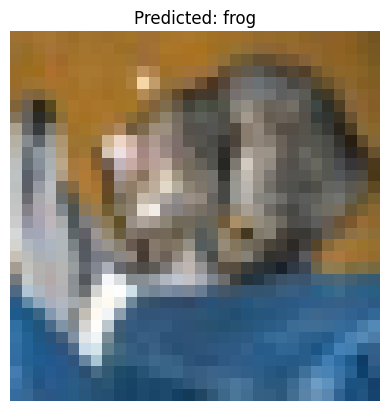

In [37]:
#ex 7
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# 2. Load pre-trained ResNet50 (without top classifier)
base_model = ResNet50(weights='imagenet', include_top=False,
                      input_shape=(32,32,3))
base_model.trainable = False   # freeze base layers

# 3. Build transfer learning model
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')   # CIFAR-10 has 10 classes
])

# 4. Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train
model.fit(x_train, y_train, epochs=1, validation_data=(x_test, y_test))

# 6. Prediction on a single test image
img = x_test[0]   # pick first test image
pred = model.predict(np.expand_dims(img, axis=0))
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print("Predicted:", classes[np.argmax(pred)])

# Show image with prediction
plt.imshow(img)
plt.title(f"Predicted: {classes[np.argmax(pred)]}")
plt.axis('off')
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0, Generator loss: 1.0209110975265503
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step


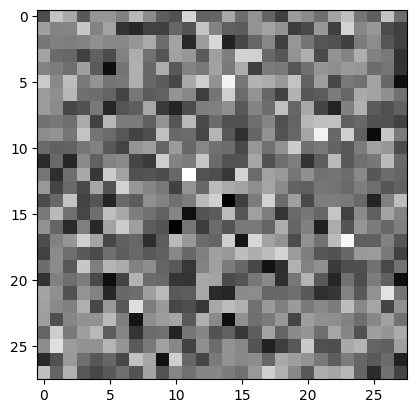

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Generator model
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(100,)),
        layers.Dense(784, activation="sigmoid"),
        layers.Reshape((28,28,1))
    ])
    return model

# Discriminator model
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

# Build GAN
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Combine models
discriminator.trainable = False
gan_input = tf.keras.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer="adam", loss="binary_crossentropy")

# Training loop (simplified)
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
x_train = np.expand_dims(x_train, axis=-1)

batch_size = 128
epochs = 10

for epoch in range(epochs):
    # Train discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_imgs = x_train[idx]
    noise = np.random.normal(0,1,(batch_size,100))
    fake_imgs = generator.predict(noise)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    # Train generator
    noise = np.random.normal(0,1,(batch_size,100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Generator loss: {g_loss}")
        sample_noise = np.random.normal(0,1,(1,100))
        gen_img = generator.predict(sample_noise)[0]
        plt.imshow(gen_img.squeeze(), cmap="gray")
        plt.show()


In [44]:
#ex 12  reinforcement algorithm for nlp problem
import numpy as np
states=["hi","bye","thanks"]
actions=["hello","goodbye","welcome"]
Q=np.zeros((3,3))
alpha=0.1
gamma=0.9
epsilon=0.2
def get_reward(state,action):
  if state==0  and action==0:
    return 1
  if state==1 and action==1:
    return 1
  if state==2 and action==2:
    return 1
  return -1

for epidose in range(100):
  state=np.random.randint(0,3)
  if np.random.rand()<epsilon:
    action=np.random.randint(0,3)
  else:
    action=np.argmax(Q[state])
  reward=get_reward(state,action)
  Q[state,action]=Q[state,action]+alpha*(reward+gamma*np.max(Q[action])-Q[state,action])
  state=action
print(Q)

print("Enter : hi/bye/thanks")
user=input()
if user in states:
  state=states.index(user)
  action=np.argmax(Q[state])
  print("Bot : ",actions[action])
else:
  print("Unknown input")

[[ 3.03586782 -0.04258433  0.00598903]
 [-0.07187123  2.60299627 -0.0732691 ]
 [-0.00580443  0.          1.9836941 ]]
Enter : hi/bye/thanks
hi
Bot :  hello


In [ ]:
#ex 4 in record
import random
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist, fashion_mnist
from tensorflow.keras.utils
import to_categorical SEED_VALUE = 42
random.seed(SEED_VALUE)
np.random.seed(SEED_VALUE)
Tf .random.set_seed(SEED_VALUE)
(X_train_all, y_train_all), (X_test, y_test) = mnist.load_data()
X_valid = X_train_all[:10000]
X_train = X_train_all[10000:]
y_valid = y_train_all[:10000]
y_train = y_train_all[10000:]
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)
plt.figure(figsize=(18, 5))
for i in range(3):
plt.subplot(1, 3, i + 1)
plt.axis(True)
plt.imshow(X_train[i], cmap='gray')
plt.subplots_adjust(wspace=0.2, hspace=0.2)
X_train = X_train.reshape((X_train.shape[0], 28 * 28))
X_train = X_train.astype("float32") / 255
X_test = X_test.reshape((X_test.shape[0], 28 * 28))
X_test = X_test.astype("float32") / 255
11
X_valid = X_valid.reshape((X_valid.shape[0], 28 * 28))
X_valid = X_valid.astype("float32") / 255
((X_train_fashion, y_train_fashion), (_, _)) = fashion_mnist.load_data()
print(y_train_fashion[0:9])
y_train_onehot = to_categorical(y_train_fashion[0:9])
print(y_train_onehot)

In [ ]:
#ex 5 record
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
plt.subplot(5,5,i+1)
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.imshow(train_images[i])
Ex. No:5
Date:20-3-2025
IMPLEMENT AN IMAGE CLASSIFIER USING CNN IN TENSORFLOW/KERAS
14
# The CIFAR labels happen to be arrays,
# which is why you need the extra index
plt.xlabel(class_names[train_labels[i][0]])
plt.show()
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.summary()
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentrop
(from_logits=True), metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images,
test_labels)) plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(test_acc)